In [237]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as LogNorm
import matplotlib.ticker as ticker
import math
import csv 
import sys

#python makeRatios.py outfile file_1 title_1 file_2 title_2 ...
#outFileName = sys.argv[1]
inFile_1 = uproot.open("../histograms/analysis_note/ratio_10.2_rho_pT_qzInt_fullUnc.root")
inFile_2 = uproot.open("../histograms/analysis_note/ratio_rga_rho_pT_qzInt_fullUnc.root")

colorList = ['red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray']


(7, 3)
(22, 5)
(2, 2)
(2, 2)


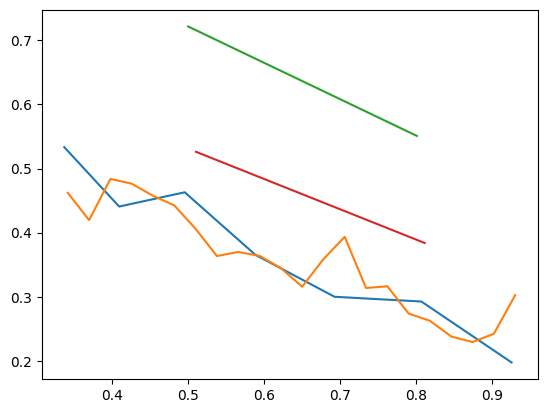

In [238]:
def ff(z):
	return (1-z)/(z+1)

z_vals = np.linspace(.3, .8, 100)
# Path to your file
file_path = ["../data/exp_data/HERMES2000.csv",
             "../data/exp_data/JLAB2012_r_Table11.csv",
              "../data/exp_data/Cornell77_xB_0.24_Q2_2.0.csv",
              "../data/exp_data/Cornell77_xB_0.5_Q2_4.0.csv"
              ]
# Load data
z=[]
r=[]
dr=[]

delim = [',',',',',',',']
label = [r'Hermes 2000: $x_B=.32, Q^2 > 1, W > 3.3$', r'JLAB 2012: $x_B=.32, Q^2=2.3, W=2.4$',  r'Cornell 1977: $x_B = 0.24, Q^2 = 2.0, W=2.7$ ', r'Cornell 1977: $x_B = 0.5, Q^2 = 4.0, W=2.7$ '
]
marker = ['x','s','^','D']

for i in range(len(file_path)):
       data = np.loadtxt(file_path[i], delimiter=delim[i], skiprows=1)
       print(data.shape)
       # If file has two columns:

       z.append(data[:, 0])
       r.append(data[:, 1] if i < 2 else (4-data[:, 1])/(4*data[:, 1] - 1))
       if i < 2:
              dr.append(data[:,2])
       else:
              dr.append(np.zeros(2)) 

       plt.plot(z[i],r[i])
      

In [239]:
def edit_ax(ax):
    ax.set_ylim( [0, 0.8] )   
    ax.set_xlim( [.3, .8] )
		
    z = np.linspace( .3, 1, 500 )
    ax.axhline( y=1, xmin=0, xmax=1 , color = 'black', linestyle = '--')
	
    ax.set_xlabel(r'$z$', fontsize=20)
    ax.set_ylabel(r'$r(z)$', fontsize=20)


In [240]:
def make_plots(inFile1, inFile2, ax, q, x, label, colorIdx):
    hist_1 = inFile1[f'hFF_0_{q+1}_{x+1}']
    
    values_1 = np.array(hist_1.values())
    values_1[values_1 <= 0] = np.nan
    if np.isnan(values_1).all():
        return
    errors_1 = np.array(hist_1.errors())

    xEdges = hist_1.axis().edges()
    binCenters = np.asarray((xEdges[:-1] + xEdges[1:]) / 2)

    label_x = r'%.2f $< x_B <$ %.2f, %.2f < $Q^2$ < %.2f [GeV]' % (
        .1 + .04*x, .1 + .04*(x+1), 2 + .5*q, 2.5 + .5*q)

    ax.tick_params(labelsize=16)
    ax.errorbar(binCenters, values_1, errors_1, marker='o',
                color=colorList[colorIdx], linestyle='',
                capsize=2, lw=1, capthick=1, label=label_x)

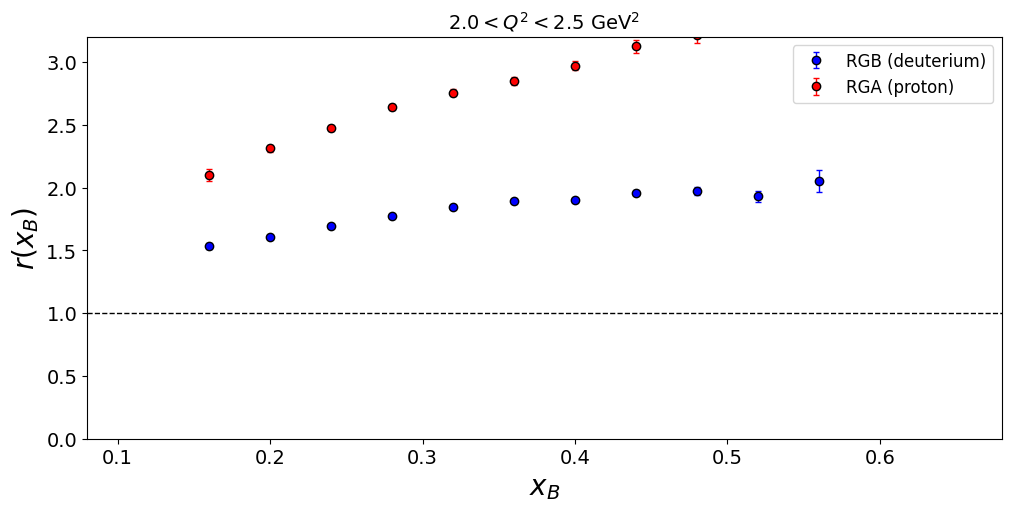

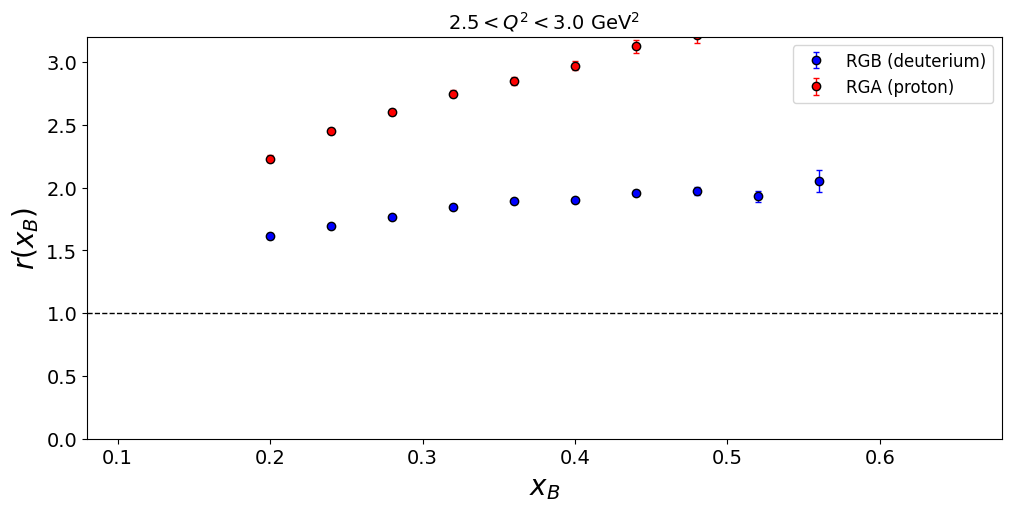

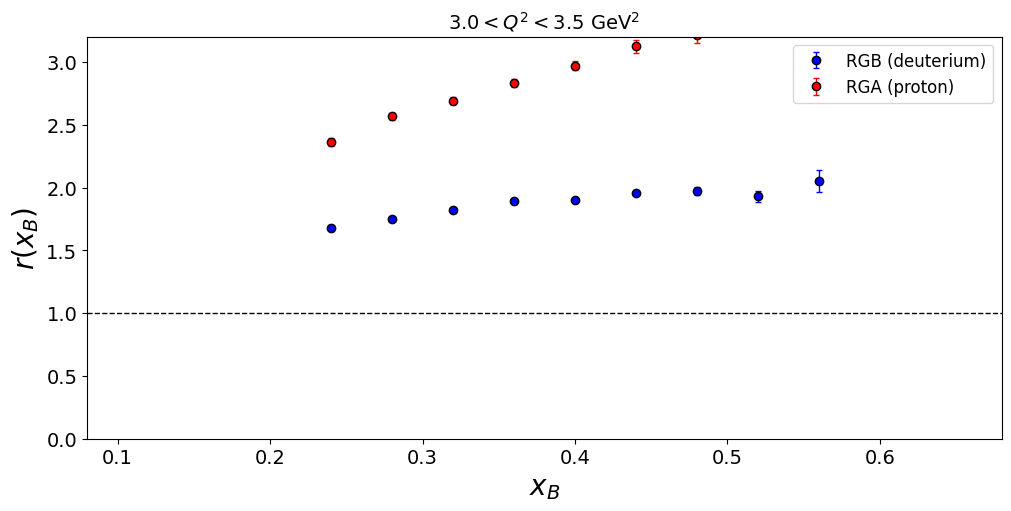

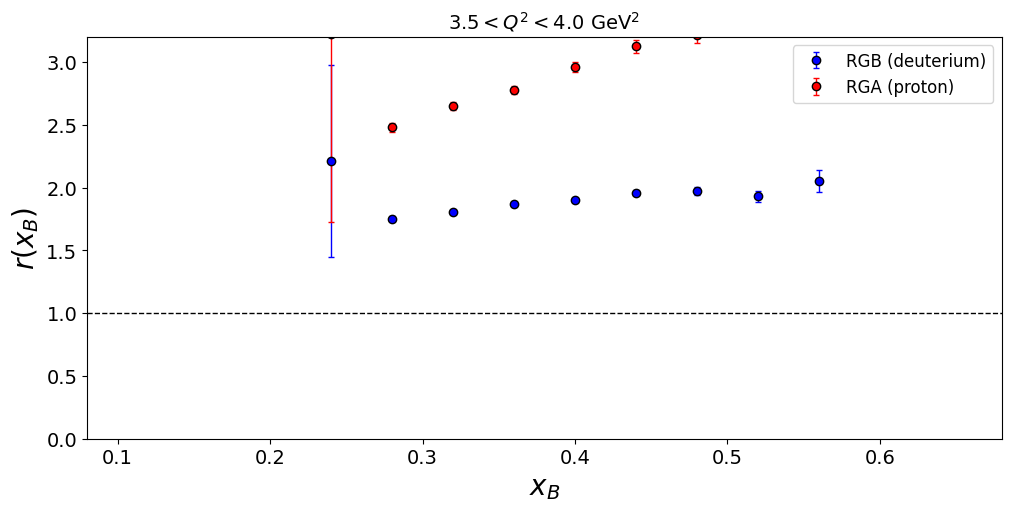

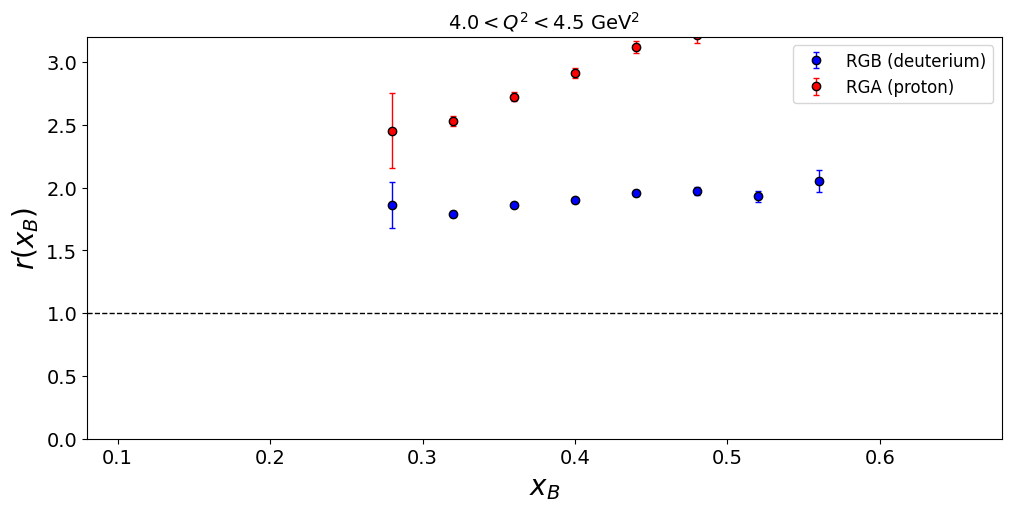

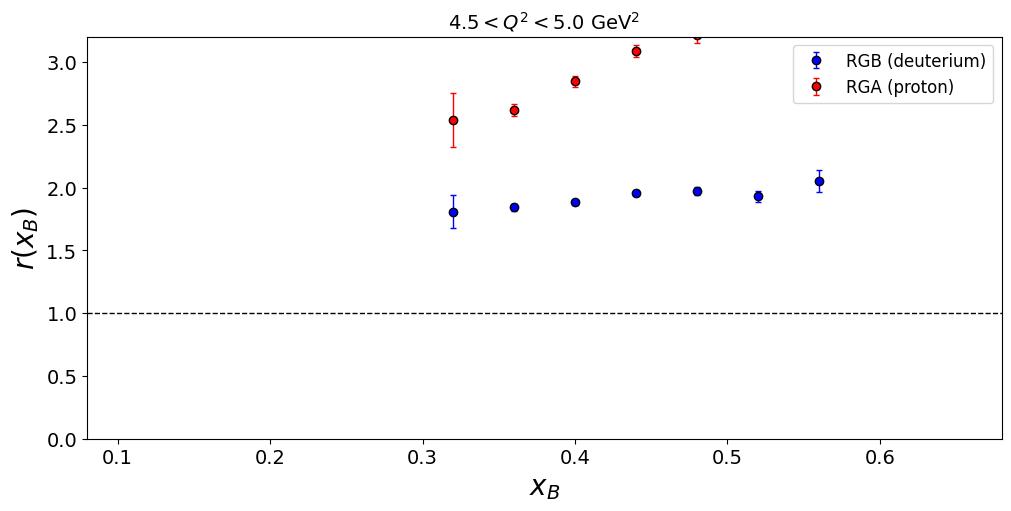

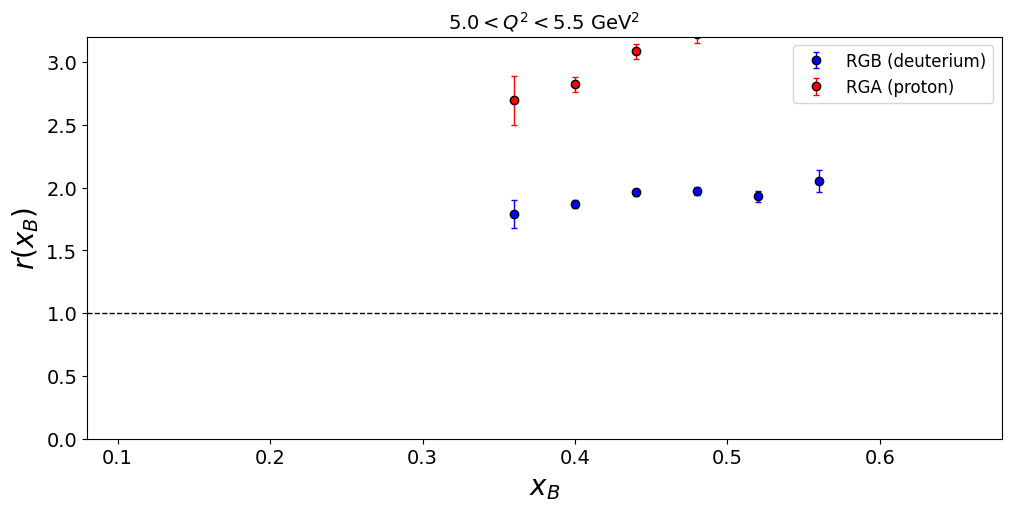

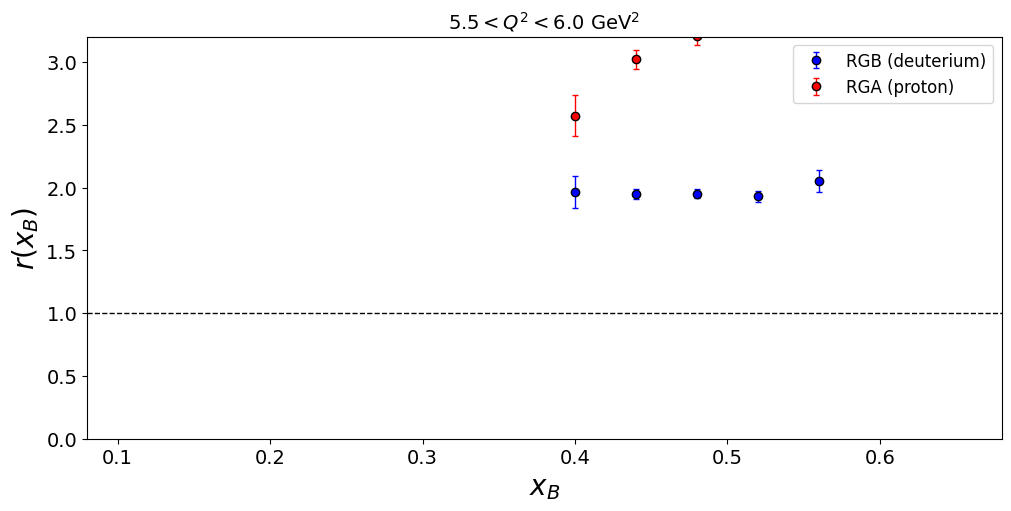

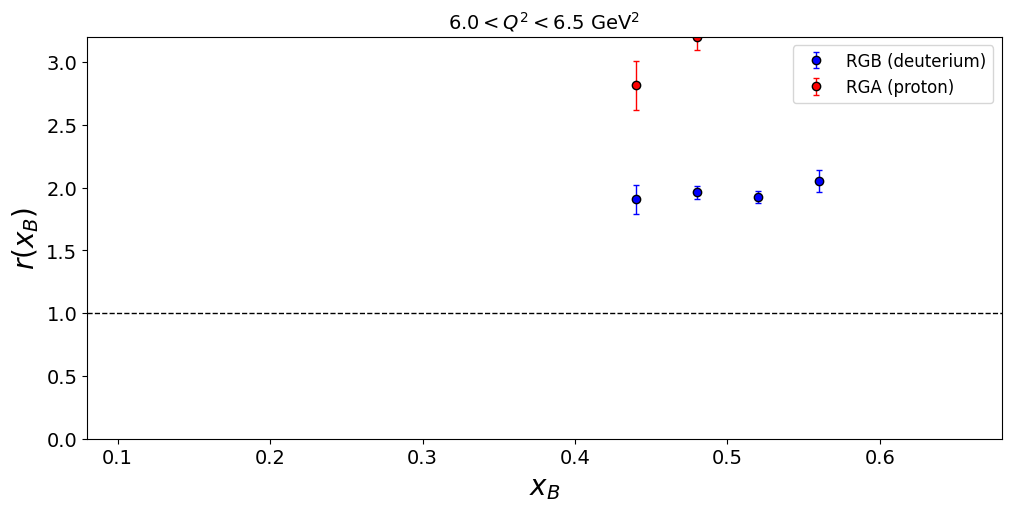

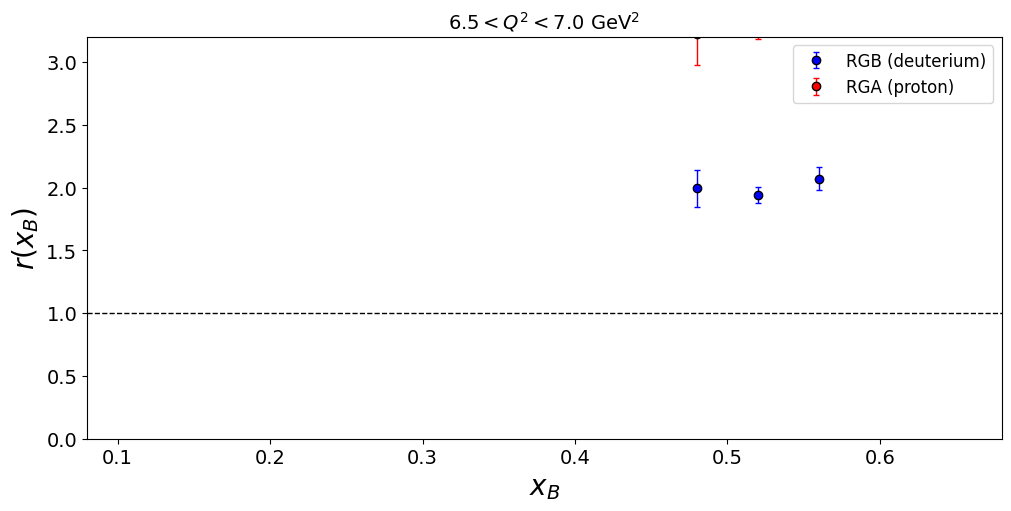

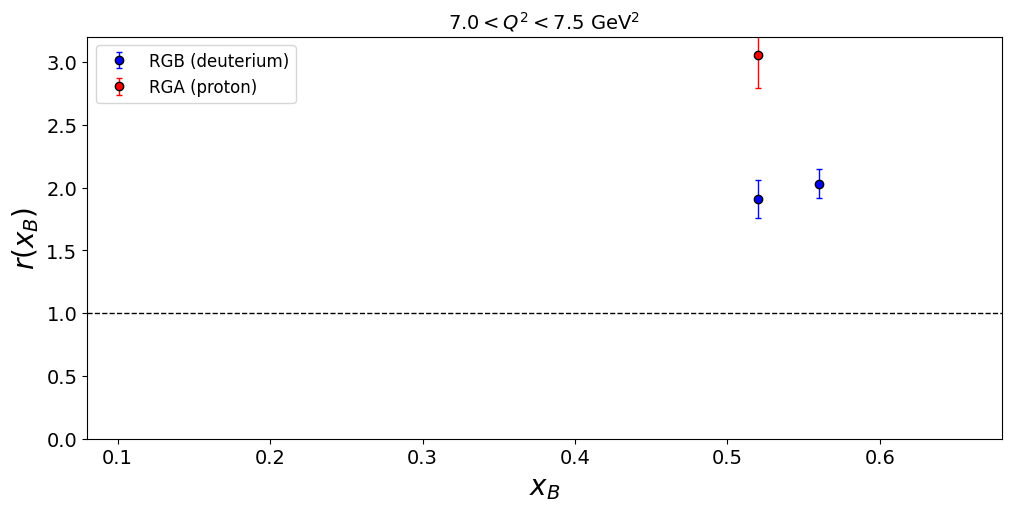

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_8344/2974987196.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


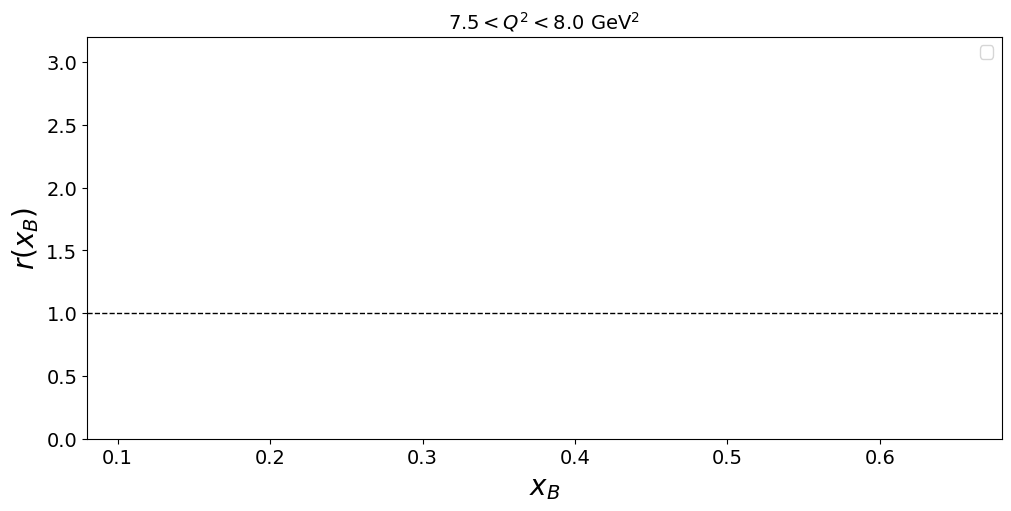

In [241]:

# ── Plot ratio as a function of xB ──────────────────────────────────────────
# For each (Q2, xB) bin, extract the z-averaged ratio from hRatio_{q+1}_{x+1}.

xB_centers = np.array([0.1 + 0.04 * (x + 0.5) for x in range(14)])

def edit_ax_x(ax):
    ax.set_ylim([0, 3.2])
    ax.set_xlim([0.08, 0.68])
    ax.axhline(y=1, color='black', linestyle='--', lw=1)
    ax.set_xlabel(r'$x_B$', fontsize=20)
    ax.set_ylabel(r'$r(x_B)$', fontsize=20)
    ax.tick_params(labelsize=14)

def get_ratio_vs_xB(inFile, q, z_slice=None):
    """Return (ratio, error) arrays indexed by xB bin.
    z_slice: (lo, hi) half-open z-bin index range to average over; None = all z bins.
    """
    ratios, errors = [], []
    for x in range(14):
        key = f'hRatio_1_{q+1}_{x+1}_1'
        if (key + ';1') not in inFile and key not in inFile:
            ratios.append(np.nan); errors.append(np.nan); continue
        hist  = inFile[key]
        vals  = np.array(hist.values())
        errs  = np.array(hist.errors())
        if z_slice is not None:
            lo, hi = z_slice
            vals, errs = vals[lo:hi], errs[lo:hi]
        mask = vals > 0
        if not mask.any():
            ratios.append(np.nan); errors.append(np.nan); continue
        w      = np.where(errs[mask] > 0, 1.0 / errs[mask]**2, 1.0)
        r_mean = np.average(vals[mask], weights=w)
        e_mean = 1.0 / np.sqrt(w.sum())
        ratios.append(r_mean)
        errors.append(e_mean)
    return np.array(ratios), np.array(errors)

files = [
    (inFile_1, 'RGB (deuterium)', 'blue'),
    (inFile_2, 'RGA (proton)',    'red'),
]

# One figure per Q2 bin
for q in range(12):
    fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
    edit_ax_x(ax)
    ax.set_title(
        rf'${2 + 0.5*q:.1f} < Q^2 < {2.5 + 0.5*q:.1f}\ \mathrm{{GeV}}^2$',
        fontsize=14
    )
    for inFile, label, color in files:
        ratios, errors = get_ratio_vs_xB(inFile, q, z_slice=(3,4))
        mask = np.isfinite(ratios)
        if mask.any():
            ax.errorbar(
                xB_centers[mask], ratios[mask], errors[mask],
                marker='o', color=color, linestyle='',
                capsize=2, lw=1, capthick=1, mec='black', label=label
            )
    ax.legend(fontsize=12)
    plt.show()


In [327]:
inFile_1 = uproot.open("../histograms/final_note/ratios_2d_rho_qInt_fullUnc.root")
inFile_2 = uproot.open("../histograms/final_note/ratios_2d_rho_rga_qInt_fullUnc.root")

def plotDoU(x):
    return 0.437076+0.455617*x-3.24114*x**2 + x**3*2.64186
x_th = np.linspace(0,.8,100)
theory = plotDoU(x_th)

[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]
[0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68]


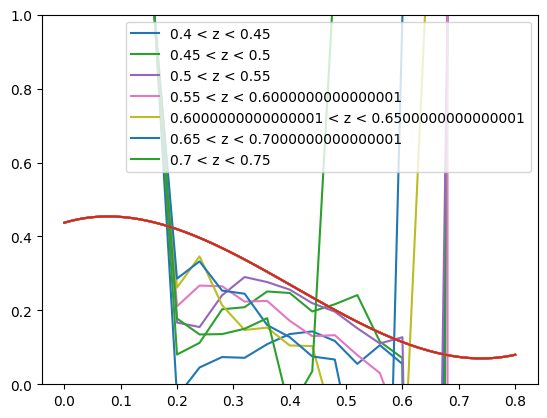

In [328]:
for z in range(2,9):
    x_range = []
    sig_d = []
    sig_p = []
    for x in range(1,15):
        key = f'hRatio_0_1_{x};1'
        
        hist  = inFile_1[key]
        vals_1  = np.array(hist.values())
        errs_1  = np.array(hist.errors())
    
        sig_d.append(vals_1[z])
        hist  = inFile_2[key]
        vals_2  = np.array(hist.values())
        errs_2  = np.array(hist.errors())

        sig_p.append(vals_2[z])

        x_range.append(.1 + 0.02+.04*x)

    edges = hist.axis().edges()
    centers = (edges[:-1] + edges[1:]) / 2




    sig_d = np.asarray(sig_d)
    sig_p = np.asarray(sig_p)
    print(x_range)
    #plt.plot(x_range, sig_d)
    #plt.plot(x_range, sig_p)

    r = (4-sig_d)/(4*sig_d - 1)
    #plt.plot(centers[r>0], r[r>0])

    dOu = 4*(1-sig_p*r)/(sig_p-r)

    plt.plot(np.asarray(x_range), dOu, label=rf'{.3+0.05*z} < z < {.3+0.05*z+.05}')
    plt.plot(x_th, theory)
    plt.ylim(0,1)
plt.legend()

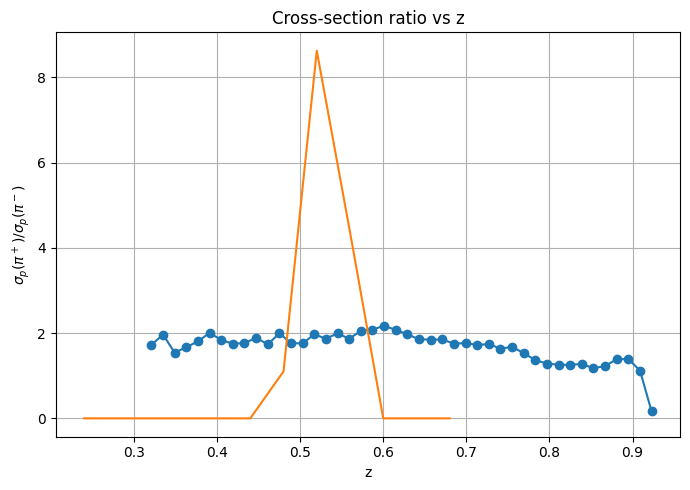

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data (central values only)
z = np.array([
0.321,0.335,0.349,0.363,0.377,0.391,0.405,0.419,0.433,0.447,
0.461,0.475,0.489,0.503,0.517,0.531,0.545,0.559,0.573,0.587,
0.601,0.615,0.629,0.643,0.657,0.671,0.685,0.699,0.713,0.727,
0.741,0.755,0.769,0.783,0.797,0.811,0.825,0.839,0.853,0.867,
0.881,0.895,0.909,0.923
])

sigma_p_plus = np.array([
5.1022,5.0775,4.5875,4.7595,3.8615,4.0219,3.8327,3.2211,3.2277,2.8839,
2.7786,2.6399,2.4154,2.2102,2.1440,1.9303,2.0077,1.6436,1.7433,1.5925,
1.4067,1.3711,1.2301,1.1113,1.1037,0.9497,0.9577,0.8742,0.8428,0.8349,
0.7730,0.7029,0.6755,0.5922,0.5987,0.6461,0.6808,0.7641,0.7667,0.8048,
0.6894,0.5098,0.2692,0.0222
])

sigma_p_minus = np.array([
2.9520,2.5860,2.9750,2.8503,2.1376,2.0030,2.0858,1.8373,1.8290,1.5252,
1.6006,1.3224,1.3694,1.2570,1.0879,1.0323,1.0071,0.8803,0.8498,0.7649,
0.6474,0.6604,0.6232,0.5993,0.5978,0.5131,0.5469,0.4948,0.4895,0.4788,
0.4720,0.4195,0.4409,0.4336,0.4654,0.5136,0.5425,0.5979,0.6530,0.6553,
0.4966,0.3664,0.2400,0.1380
])

# Ratio
ratio = sigma_p_plus / sigma_p_minus

# Plot
plt.figure(figsize=(7,5))
plt.plot(z, ratio, marker='o', linestyle='-')
plt.plot(x_range, sig_p)
#plt.plot(centers[sig_p>0], sig_p[sig_p>0])

plt.xlabel('z')
plt.ylabel(r'$\sigma_p(\pi^+)/\sigma_p(\pi^-)$')
plt.title('Cross-section ratio vs z')
plt.grid(True)



plt.tight_layout()
plt.show()

In [ ]:
inFile_1 = uproot.open("../histograms/analysis_note/ratio_2d_rho_fullUnc.root")
inFile_2 = uproot.open("../histograms/analysis_note/ratio_rga_rho_fullUnc.root")
key = f'hRatio_0_4_6_1;1'

hist  = inFile_1[key]
sig_d  = np.array(hist.values())
errs_1  = np.array(hist.errors())
   
hist  = inFile_2[key]
sig_p  = np.array(hist.values())
errs_2  = np.array(hist.errors())


edges = hist.axis().edges()
centers = (edges[:-1] + edges[1:]) / 2


#plt.plot(centers[sig_d>0], sig_d[sig_d>0])
#plt.plot(centers[sig_p>0], sig_p[sig_p>0])

r = (4-sig_d)/(4*sig_d - 1)
#plt.plot(centers[r>0], r[r>0])

dOu = 4*(1-sig_p*r)/(sig_p-r)
#plt.plot(centers, sig_p)
#plt.plot(centers[r>0], sig_d[r>0])
plt.ylim([0,1])
plt.plot(centers[dOu>0], dOu[dOu>0])
print(np.sum(sigma_p_plus)/np.sum(sigma_p_minus))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/../histograms/analysis_note/ratio_2d_rho_fullUnc.root'

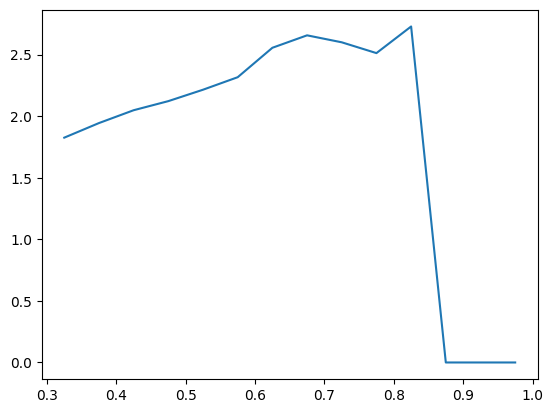

In [ ]:
inFile_1 = uproot.open("../histograms/analysis_note/ratios_3d_qInt.root")
inFile_2 = uproot.open("../histograms/analysis_note/ratios_3d_rga_qInt.root")
key = f'hRatio_0_2_6_1;1'

hist  = inFile_1[key]
sig_d  = np.array(hist.values())
errs_1  = np.array(hist.errors())
   
hist  = inFile_2[key]
sig_p  = np.array(hist.values())
errs_2  = np.array(hist.errors())


edges = hist.axis().edges()
centers = (edges[:-1] + edges[1:]) / 2


#plt.plot(centers[sig_d>0], sig_d[sig_d>0])
#plt.plot(centers[sig_p>0], sig_p[sig_p>0])

r = (4-sig_d)/(4*sig_d - 1)
#plt.plot(centers[r>0], r[r>0])

dOu = 4*(1-sig_p*r)/(sig_p-r)
plt.plot(centers, sig_p)
#plt.plot(centers[r>0], sig_d[r>0])

#plt.plot(centers[dOu>0], dOu[dOu>0])
#print(np.sum(sigma_p_plus)/np.sum(sigma_p_minus))


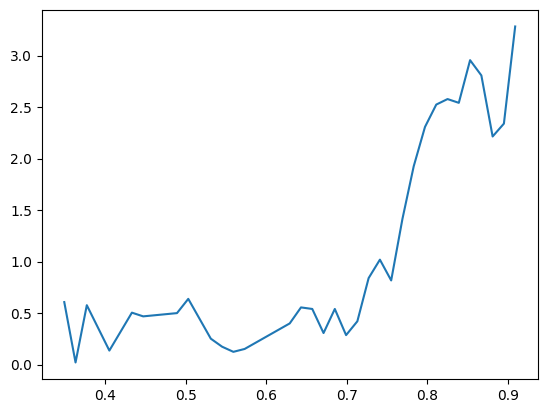

In [ ]:
"""
Table I from Navasardyan et al., "The Onset of Quark-Hadron Duality in Pion
Electroproduction", arXiv:hep-ph/0608214 (PRL 98, 022001, 2007).
 
Cross sections in nb/GeV^3/sr at fixed (x, Q^2) = (0.32, 2.30 GeV^2),
as a function of z = E_pi / nu. Errors are statistical only.
 
Columns:
    z          - pion energy fraction
    sigma_p_pip - sigma(p, pi+)
    sigma_p_pim - sigma(p, pi-)
    sigma_d_pip - sigma(d, pi+)
    sigma_d_pim - sigma(d, pi-)
 
`*_err` arrays are the statistical uncertainties on the corresponding column.
"""
 
import numpy as np
 
z = np.array([
    0.321, 0.335, 0.349, 0.363, 0.377, 0.391, 0.405, 0.419, 0.433, 0.447,
    0.461, 0.475, 0.489, 0.503, 0.517, 0.531, 0.545, 0.559, 0.573, 0.587,
    0.601, 0.615, 0.629, 0.643, 0.657, 0.671, 0.685, 0.699, 0.713, 0.727,
    0.741, 0.755, 0.769, 0.783, 0.797, 0.811, 0.825, 0.839, 0.853, 0.867,
    0.881, 0.895, 0.909, 0.923,
])
 
sigma_p_pip = np.array([
    5.1022, 5.0775, 4.5875, 4.7595, 3.8615, 4.0219, 3.8327, 3.2211, 3.2277, 2.8839,
    2.7786, 2.6399, 2.4154, 2.2102, 2.1440, 1.9303, 2.0077, 1.6436, 1.7433, 1.5925,
    1.4067, 1.3711, 1.2301, 1.1113, 1.1037, 0.9497, 0.9577, 0.8742, 0.8428, 0.8349,
    0.7730, 0.7029, 0.6755, 0.5922, 0.5987, 0.6461, 0.6808, 0.7641, 0.7667, 0.8048,
    0.6894, 0.5098, 0.2692, 0.0222,
])
sigma_p_pip_err = np.array([
    0.9260, 0.3760, 0.2620, 0.2211, 0.1674, 0.1484, 0.1381, 0.1261, 0.1103, 0.1027,
    0.1018, 0.1016, 0.0954, 0.0884, 0.0832, 0.0812, 0.0799, 0.0720, 0.0643, 0.0566,
    0.0504, 0.0478, 0.0441, 0.0393, 0.0365, 0.0322, 0.0320, 0.0296, 0.0286, 0.0283,
    0.0261, 0.0222, 0.0216, 0.0192, 0.0194, 0.0192, 0.0199, 0.0213, 0.0212, 0.0210,
    0.0212, 0.0209, 0.0232, 0.0350,
])
 
sigma_p_pim = np.array([
    2.9520, 2.5860, 2.9750, 2.8503, 2.1376, 2.0030, 2.0858, 1.8373, 1.8290, 1.5252,
    1.6006, 1.3224, 1.3694, 1.2570, 1.0879, 1.0323, 1.0071, 0.8803, 0.8498, 0.7649,
    0.6474, 0.6604, 0.6232, 0.5993, 0.5978, 0.5131, 0.5469, 0.4948, 0.4895, 0.4788,
    0.4720, 0.4195, 0.4409, 0.4336, 0.4654, 0.5136, 0.5425, 0.5979, 0.6530, 0.6553,
    0.4966, 0.3664, 0.2400, 0.1380,
])
sigma_p_pim_err = np.array([
    0.6990, 0.2920, 0.2130, 0.1767, 0.1349, 0.1192, 0.1150, 0.1061, 0.0876, 0.0765,
    0.0734, 0.0671, 0.0610, 0.0533, 0.0461, 0.0441, 0.0410, 0.0367, 0.0319, 0.0282,
    0.0251, 0.0244, 0.0236, 0.0217, 0.0197, 0.0180, 0.0191, 0.0177, 0.0177, 0.0171,
    0.0165, 0.0147, 0.0156, 0.0145, 0.0155, 0.0163, 0.0166, 0.0177, 0.0186, 0.0171,
    0.0144, 0.0131, 0.0122, 0.0120,
])
 
sigma_d_pip = np.array([
    6.9866, 8.0795, 7.1233, 6.6510, 6.3132, 5.6805, 5.7105, 4.9272, 4.8902, 4.6133,
    3.8764, 3.7653, 3.5153, 3.5419, 2.9755, 2.8307, 2.7786, 2.4638, 2.3350, 2.1198,
    2.1260, 1.9290, 1.9385, 1.7834, 1.6701, 1.4767, 1.4249, 1.3854, 1.3738, 1.4706,
    1.3586, 1.2689, 1.2450, 1.2769, 1.3623, 1.4704, 1.5252, 1.6375, 1.6277, 1.6313,
    1.4526, 1.0932, 0.7644, 0.5219,
])
sigma_d_pip_err = np.array([
    1.2920, 0.5360, 0.3650, 0.3062, 0.2364, 0.2063, 0.1963, 0.1762, 0.1742, 0.1460,
    0.1357, 0.1338, 0.1226, 0.1153, 0.1064, 0.1048, 0.1125, 0.0944, 0.0800, 0.0734,
    0.0714, 0.0660, 0.0636, 0.0573, 0.0508, 0.0459, 0.0432, 0.0427, 0.0423, 0.0431,
    0.0396, 0.0345, 0.0336, 0.0340, 0.0360, 0.0375, 0.0375, 0.0397, 0.0369, 0.0341,
    0.0311, 0.0279, 0.0274, 0.0365,
])
 
sigma_d_pim = np.array([
    6.8482, 5.6131, 5.0146, 4.8947, 3.9476, 4.2287, 3.8901, 3.7896, 3.1669, 2.8639,
    3.0718, 2.7262, 2.2797, 2.2285, 2.0947, 1.8624, 1.7867, 1.6663, 1.4832, 1.4626,
    1.3834, 1.2753, 1.1877, 1.0988, 1.0364, 0.9665, 0.9206, 0.9392, 0.9225, 0.8840,
    0.8252, 0.7955, 0.7247, 0.7418, 0.7660, 0.7862, 0.7965, 0.8278, 0.8383, 0.7840,
    0.7161, 0.4969, 0.3685, 0.2641,
])
sigma_d_pim_err = np.array([
    3.3984, 1.2928, 0.8896, 0.7571, 0.5645, 0.5348, 0.4964, 0.4676, 0.3816, 0.3530,
    0.3539, 0.3348, 0.2849, 0.2474, 0.2295, 0.2091, 0.1958, 0.1816, 0.1527, 0.1479,
    0.1430, 0.1339, 0.1289, 0.1162, 0.1036, 0.0979, 0.0923, 0.0925, 0.0924, 0.0887,
    0.0821, 0.0732, 0.0674, 0.0674, 0.0687, 0.0692, 0.0697, 0.0698, 0.0670, 0.0598,
    0.0574, 0.0500, 0.0512, 0.0630,
])
 
assert len(z) == 44
assert all(len(a) == 44 for a in [sigma_p_pip, sigma_p_pip_err,
                                  sigma_p_pim, sigma_p_pim_err,
                                  sigma_d_pip, sigma_d_pip_err,
                                  sigma_d_pim, sigma_d_pim_err])

r_p = sigma_p_pip/sigma_p_pim
r_d = sigma_d_pip/sigma_d_pim

#plt.plot(z, r_p)
#plt.plot(z, r_d)

R = (4-r_d)/(4*r_d - 1)

dOu = 4*(1-r_p*R)/(r_p-R)
#plt.plot(z, R)
plt.plot( z[dOu>0],   dOu[dOu>0])